In [23]:
if (!require("pacman")) install.packages("pacman")

pacman::p_load(
  tidyverse,
  haven,
  knitr, scales,patchwork
)

In [58]:
# =========================
#DATOS EAT
# =========================

eat <- tibble::tribble(
  ~modo, ~anio, ~g_total, ~g_combustibles, ~g_peaje_infra, ~g_placas_lic, ~i_total, ~i_trans_cg, ~i_serv_logis,

  "Ferroviario", 2018, 32971010000, 9723394000, 451679000, 9595000, 63702907000, 60732039000, 0,
  "Ferroviario", 2019, 34462657000, 11156748000, 441544000, 4870000, 65773203000, 63797975000, 0,
  "Ferroviario", 2020, 31362459000, 9410146000, 429535000, 4959000, 66479322000, 64524585000, 137462000,
  "Ferroviario", 2021, 31596230000, 11161548000, 59187000, 7410000, 72520239000, 70122531000, 115835000,
  "Ferroviario", 2022, 33667356000, 12918315000, 72547000, 14236000, 79177222000, 76730700000, 122082000,
  "Ferroviario", 2023, 33928758000, 13068992000, 67108000, 13694000, 83468170000, 80981823000, 119200000,
  "Ferroviario",    2024,  37963915000,  14939421000,    98646000,   17145000,  92421220000,  90304371000,   58829000,
  "Autotransporte", 2018, 175937286000, 85263300000, 17944888000, 590389000, 292260527000, 286555911000, 457774000,
  "Autotransporte", 2019, 188370964000, 89365835000, 19311493000, 586098000, 310839303000, 303652223000, 1229668000,
  "Autotransporte", 2020, 176752029000, 80842897000, 18120936000, 553712000, 322775292000, 312652536000, 2910111000,
  "Autotransporte", 2021, 224248858000, 106787155000, 22375541000, 583465000, 356462026000, 347192582000, 2688642000,
  "Autotransporte", 2022, 232585803000, 107243106000, 25442697000, 652080000, 399095883000, 386732690000, 3483065000,
  "Autotransporte", 2023, 219281595000, 101170744000, 26934680000, 663184000, 394564571000, 382146767000, 3632344000,
    "Autotransporte", 2024,  261955777000, 114968430000, 28810875000, 1165467000,  518897224000,  487966282000,  4042027000
)

# pasar a millones 
eat <- eat %>%
  mutate(across(c(g_total:i_serv_logis), ~ .x / 1e6))

# =========================
#IEPS
# =========================

ieps <- tibble::tribble(
  ~anio, ~ieps_pxl, ~precio_diesel_pxl,
  2018, 4.58, 17.86,
  2019, 4.80, 19.59,
  2020, 5.44, 18.70,
  2021, 5.69, 20.44,
  2022, 6.17, 23.30,
  2023, 6.51, 23.50,
   2024,  6.79,  25.10
) %>%
  mutate(pct_ieps = ieps_pxl / precio_diesel_pxl)


tarifas_ferro <- tibble::tribble(
  ~operador, ~anio_aar, ~rate_usd_tonmi,
  "FXE", 2019, 0.09685,
  "FXE", 2020, 0.08854,
  "FXE", 2021, 0.09392,
  "KCSM", 2019, 0.07338,
  "KCSM", 2020, 0.07040,
  "KCSM", 2021, 0.06947
)

tarifas_ferro <- tarifas_ferro %>%
  mutate(tc = case_when(
    anio_aar == 2019 ~ 19.26,
    anio_aar == 2020 ~ 21.49,
    anio_aar == 2021 ~ 20.28
  ))

  tarifas_ferro <- tarifas_ferro %>%
  mutate(tarifa_mxp_tonkm = rate_usd_tonmi * tc / 1.60934)


  v_F_FXE <- tarifas_ferro %>%
  filter(operador == "FXE") %>%
  summarise(mean(tarifa_mxp_tonkm)) %>%
  pull()

v_F_KCSM <- tarifas_ferro %>%
  filter(operador == "KCSM") %>%
  summarise(mean(tarifa_mxp_tonkm)) %>%
  pull()


# =========================
# MERGE + INDICADORES
# =========================

df <- eat %>%
  left_join(ieps, by = "anio") %>%
  mutate(
    ICC = g_combustibles / g_total,
    ICI = g_combustibles / i_total,
    PEC = i_total / g_combustibles,
    CRI = (g_peaje_infra + g_placas_lic) / g_total
  )

  df_indica<-df%>%
  filter(anio<2024)

# =========================
#PROMEDIOS 2018–2023
# =========================

resumen <- df_indica %>%
  group_by(modo) %>%
  summarise(
    ICC = mean(ICC),
    ICI = mean(ICI),
    PEC = mean(PEC),
    CRI = mean(CRI),
    .groups = "drop"
  )

# IEPS promedio
ieps_mean <- mean(ieps$pct_ieps)

# efecto IEPS (canal ICI)
resumen <- resumen %>%
  mutate(
    IEPS_pct = ieps_mean,
    Canal_IEPS = -ICI * ieps_mean   
  )

  # =========================
#MODELO DE CRUCE
# =========================

F_A <- 150
v_A <- 3.80
F_F <- 1200

# tarifa ferroviaria promedio 
v_F <- 1.175  

# ICC autotransporte
ICC_auto <- resumen$ICC[resumen$modo=="Autotransporte"]

# IEPS 2021
ieps21 <- 5.69 / 20.44

# costo con IEPS
v_A_fuel <- v_A * ICC_auto
v_A_nofu <- v_A * (1 - ICC_auto)
v_A_ieps <- v_A_nofu + v_A_fuel * (1 - ieps21)

# cruces
d_sin <- (F_F - F_A) / (v_A - v_F)
d_con <- (F_F - F_A) / (v_A_ieps - v_F)

buffer_km <- d_con - d_sin
buffer_pct <- buffer_km / d_sin

### Tablas y gráficas

In [ ]:
## Tabla 1

tabla <- tibble::tibble(
  Indicador = c(
    "ICC: Combustible / Gastos ByS",
    "ICI: Combustible / Ingresos",
    "PEC: Ingresos / Combustible",
    "CRI: (Peajes + Placas) / Gastos ByS",
    "IEPS como % del precio del diésel",
    "Canal IEPS (reducción ICI)",
    "Punto de cruce AT vs. FFCC sin IEPS",
    "Punto de cruce AT vs. FFCC con IEPS",
    "Buffer kilométrico del estímulo IEPS"
  ),
  Autotransporte = c(
    resumen$ICC[resumen$modo=="Autotransporte"],
    resumen$ICI[resumen$modo=="Autotransporte"],
    resumen$PEC[resumen$modo=="Autotransporte"],
    resumen$CRI[resumen$modo=="Autotransporte"],
    ieps_mean,
    resumen$Canal_IEPS[resumen$modo=="Autotransporte"],
    d_sin,
    d_con,
    buffer_km
  ),
  Ferroviario = c(
    resumen$ICC[resumen$modo=="Ferroviario"],
    resumen$ICI[resumen$modo=="Ferroviario"],
    resumen$PEC[resumen$modo=="Ferroviario"],
    resumen$CRI[resumen$modo=="Ferroviario"],
    NA,
    NA,
    NA,
    NA,
    NA
  )
)

tabla

Indicador,Autotransporte,Ferroviario
<chr>,<dbl>,<dbl>
ICC: Combustible / Gastos ByS,0.46918018,0.340139346
ICI: Combustible / Ingresos,0.27573317,0.156242003
PEC: Ingresos / Combustible,3.64301748,6.420775898
CRI: (Peajes + Placas) / Gastos ByS,0.10951129,0.007977455
IEPS como % del precio del diésel,0.26901326,NA
Canal IEPS (reducción ICI),-0.07417588,NA
Punto de cruce AT vs. FFCC sin IEPS,400.00000000,NA
Punto de cruce AT vs. FFCC con IEPS,493.26153831,NA
Buffer kilométrico del estímulo IEPS,93.26153831,NA


In [60]:
df_plot <- df %>%
  mutate(
    modo = factor(modo, levels = c("Autotransporte", "Ferroviario")),
MCS = (i_total - g_total) / i_total,
    ICG = i_trans_cg / i_total,
    ILX = i_serv_logis / i_total


)

  colores <- c(
  "Autotransporte" = "#1f3b73",   # azul
  "Ferroviario" = "#d4a017"       # dorado
)

In [61]:
p1 <- ggplot(df_plot, aes(anio, ICC, color = modo)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  scale_color_manual(values = colores) +
  labs(title = "ICC: Combustible / Costos ByS", y = "", x = "") +
  theme_minimal()


  p2 <- ggplot(df_plot, aes(anio, ICI, color = modo)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  scale_color_manual(values = colores) +
  labs(title = "ICI: Combustible / Ingresos", y = "", x = "") +
  theme_minimal()

p3 <- ggplot(df_plot, aes(anio, PEC, color = modo)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  scale_color_manual(values = colores) +
  labs(title = "PEC: Ingresos / Combustible", y = "", x = "") +
  theme_minimal()

p4 <- ggplot(df_plot, aes(anio, CRI, color = modo)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  scale_color_manual(values = colores) +
  labs(title = "CRI: (Peajes + Placas) / Costos ByS", y = "", x = "") +
  theme_minimal()

p5 <- ggplot(df_plot, aes(anio, MCS, color = modo)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  scale_color_manual(values = colores) +
  labs(title = "MCS: (Ingresos - Costos ByS) / Ingresos", y = "", x = "") +
  theme_minimal()


  p6 <- ggplot(df_plot) +
  geom_line(aes(anio, ICG, color = modo), size = 1) +
  geom_line(aes(anio, ILX, color = modo), linetype = "dashed", size = 1) +
  scale_color_manual(values = colores) +
  labs(title = "Estructura de Ingresos por Modo", y = "", x = "") +
  theme_minimal()

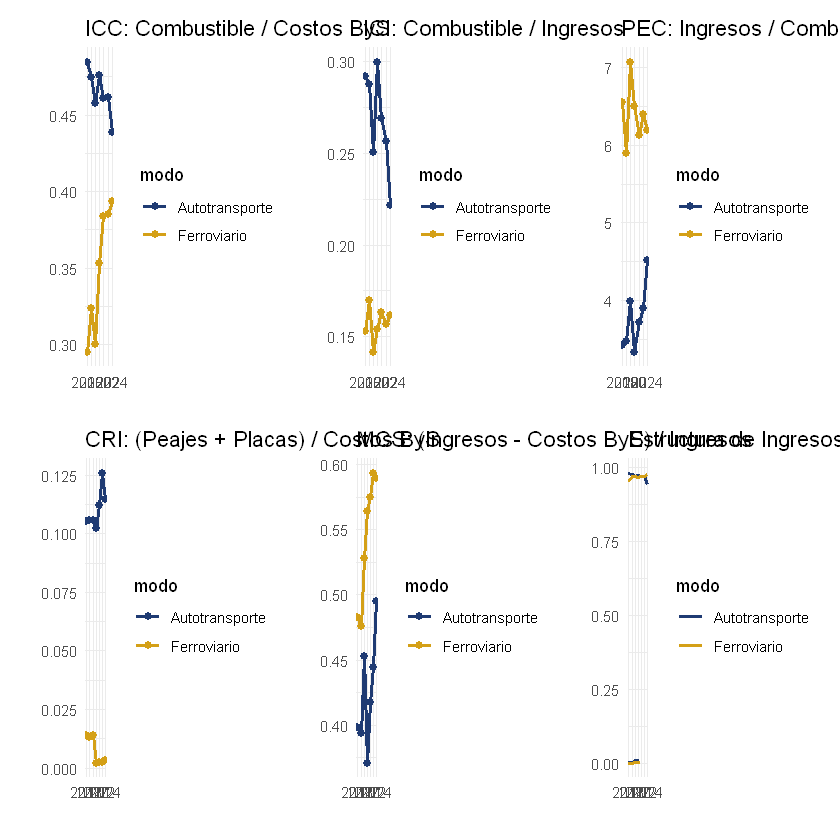

In [ ]:
#Figura 1
figura <- (p1 + p2 + p3) /
          (p4 + p5 + p6)

figura

In [63]:
curvas <- tibble::tibble(
  d = seq(0, 3200, by = 10)
)

ieps21 <- 5.69 / 20.44

v_A_fuel <- v_A * ICC_auto
v_A_nofu <- v_A * (1 - ICC_auto)
v_A_ieps <- v_A_nofu + v_A_fuel * (1 - ieps21)

# escenarios alternativos
v_A_huach <- v_A * (1 - ICC_auto)
v_A_inf   <- v_A * 0.85
F_A_inf   <- F_A * 0.70
v_A_sob   <- v_A / 1.25
F_A_sob   <- F_A / 1.25

curvas <- curvas %>%
  mutate(
    T_AT_formal = F_A + v_A * d,
    T_AT_ieps   = F_A + v_A_ieps * d,
    T_AT_huach  = F_A + v_A_huach * d,
    T_AT_inf    = F_A_inf + v_A_inf * d,
    T_AT_sob    = F_A_sob + v_A_sob * d,
    T_FFCC_FXE  = F_F + v_F_FXE * d,
    T_FFCC_KCSM = F_F + v_F_KCSM * d
  )

In [64]:
d_sin <- (F_F - F_A) / (v_A - v_F_FXE)
d_con <- (F_F - F_A) / (v_A_ieps - v_F_FXE)

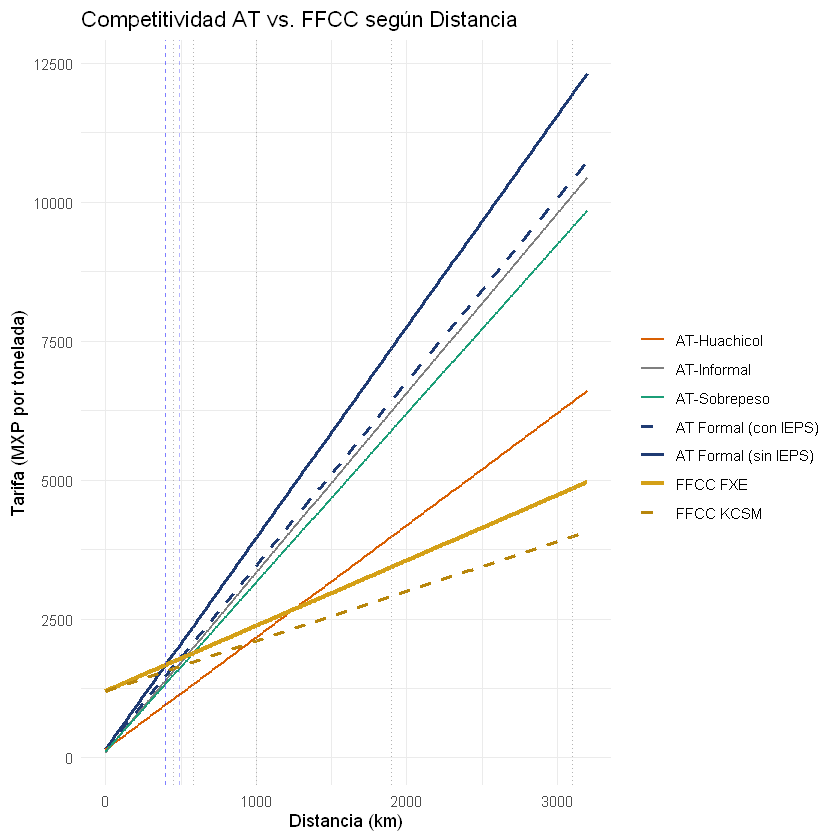

In [ ]:
## Figura 2

ggplot(curvas, aes(x = d)) +

  # Autotransporte
  geom_line(aes(y = T_AT_formal, color = "AT Formal (sin IEPS)"), size = 1) +
  geom_line(aes(y = T_AT_ieps, color = "AT Formal (con IEPS)"), linetype = "dashed", size = 1) +
  geom_line(aes(y = T_AT_huach, color = "AT-Huachicol"), size = 0.8) +
  geom_line(aes(y = T_AT_inf, color = "AT-Informal"), size = 0.8) +
  geom_line(aes(y = T_AT_sob, color = "AT-Sobrepeso"), size = 0.8) +

  # Ferrocarril
  geom_line(aes(y = T_FFCC_FXE, color = "FFCC FXE"), size = 1.2) +
  geom_line(aes(y = T_FFCC_KCSM, color = "FFCC KCSM"), linetype = "dashed", size = 1) +

  # líneas verticales (cruces + corredores)
  geom_vline(xintercept = d_sin, linetype = "dashed", color = "blue", alpha = 0.5) +
  geom_vline(xintercept = d_con, linetype = "dashed", color = "blue", alpha = 0.3) +

  geom_vline(xintercept = c(450, 580, 1000, 1900, 3100),
             linetype = "dotted", color = "gray70") +
             scale_color_manual(values = c(
  "AT Formal (sin IEPS)" = "#1f3b73",
  "AT Formal (con IEPS)" = "#1f3b73",
  "AT-Huachicol" = "#d95f02",
  "AT-Informal" = "#7f7f7f",
  "AT-Sobrepeso" = "#1b9e77",
  "FFCC FXE" = "#d4a017",
  "FFCC KCSM" = "#b8860b"
))+

  labs(
    title = "Competitividad AT vs. FFCC según Distancia",
    x = "Distancia (km)",
    y = "Tarifa (MXP por tonelada)",
    color = ""
  ) +

  theme_minimal()

In [76]:
corredores <- tibble::tibble(
  corredor = c(
    "México–Veracruz",
    "México–Guadalajara",
    "México–Monterrey",
    "México–Cd. Juárez",
    "México–Mexicali"
  ),
  distancia = c(450, 580, 1000, 1900, 3100)
)

corredores <- corredores %>%
  mutate(
    T_A_sin  = F_A + v_A * distancia,
    T_A_ieps = F_A + v_A_ieps * distancia,
    T_F      = F_F + v_F * distancia,

    ahorro_ieps = T_A_sin - T_A_ieps,
    ahorro_pct  = ahorro_ieps / T_A_sin * 100,

    ventaja_ffcc = (T_A_ieps - T_F) / T_A_ieps * 100
  )

  corredores <- corredores %>%
  mutate(
    ganador = case_when(
      T_F < T_A_ieps ~ paste0("FFCC (+", round(ventaja_ffcc,1), "%)"),
      TRUE ~ "AT (+IEPS)"
    )
  )

  corredores <- corredores %>%
  mutate(
    adv_vs_formal = (T_A_sin - T_F) / T_A_sin * 100,
    adv_vs_ieps   = (T_A_ieps - T_F) / T_A_ieps * 100
  )

  corredores <- corredores %>%
  mutate(
    corredor = factor(
      corredor,
      levels = rev(c(
        "México–Veracruz",
        "México–Guadalajara",
        "México–Monterrey",
        "México–Cd. Juárez",
        "México–Mexicali"
      ))
    )
  )

In [ ]:
#Tabla 2

tabla_f <- corredores %>%
  transmute(
    Corredor = corredor,
    kms = distancia,
    `T_A sin IEPS` = round(T_A_sin),
    `T_A con IEPS` = round(T_A_ieps),
    `T_F` = round(T_F),
    `Ahorro IEPS` = paste0("$", round(ahorro_ieps), " (", round(ahorro_pct,1), "%)"),
    `Ganador actual` = ganador
  )

tabla_f

Corredor,kms,T_A sin IEPS,T_A con IEPS,T_F,Ahorro IEPS,Ganador actual
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
México–Veracruz,450,1860,1637,1729,$223 (12%),AT (+IEPS)
México–Guadalajara,580,2354,2066,1882,$288 (12.2%),FFCC (+8.9%)
México–Monterrey,1000,3950,3454,2375,$496 (12.6%),FFCC (+31.2%)
México–Cd. Juárez,1900,7370,6427,3432,$943 (12.8%),FFCC (+46.6%)
México–Mexicali,3100,11930,10391,4842,$1539 (12.9%),FFCC (+53.4%)


In [105]:
df_plot_bar <- corredores %>%
  select(corredor, adv_vs_formal, adv_vs_ieps) %>%
  pivot_longer(
    cols = c(adv_vs_formal, adv_vs_ieps),
    names_to = "tipo",
    values_to = "valor"
  ) %>%
  mutate(
    tipo = recode(tipo,
      adv_vs_formal = "vs. AT Formal (sin IEPS)",
      adv_vs_ieps   = "vs. AT con IEPS (actual)"
    ),
    corredor = factor(
      corredor,
    levels = rev(c(
      "México–Mexicali",
      "México–Cd. Juárez",
      "México–Monterrey",
      "México–Guadalajara",
      "México–Veracruz"
    )
    ))
  )
  df_plot_bar

corredor,tipo,valor
<fct>,<chr>,<dbl>
México–Veracruz,vs. AT Formal (sin IEPS),7.056452
México–Veracruz,vs. AT con IEPS (actual),-5.626724
México–Guadalajara,vs. AT Formal (sin IEPS),20.072218
México–Guadalajara,vs. AT con IEPS (actual),8.936433
México–Monterrey,vs. AT Formal (sin IEPS),39.873418
México–Monterrey,vs. AT con IEPS (actual),31.232935
México–Cd. Juárez,vs. AT Formal (sin IEPS),53.426052
México–Cd. Juárez,vs. AT con IEPS (actual),46.592563
México–Mexicali,vs. AT Formal (sin IEPS),59.409053


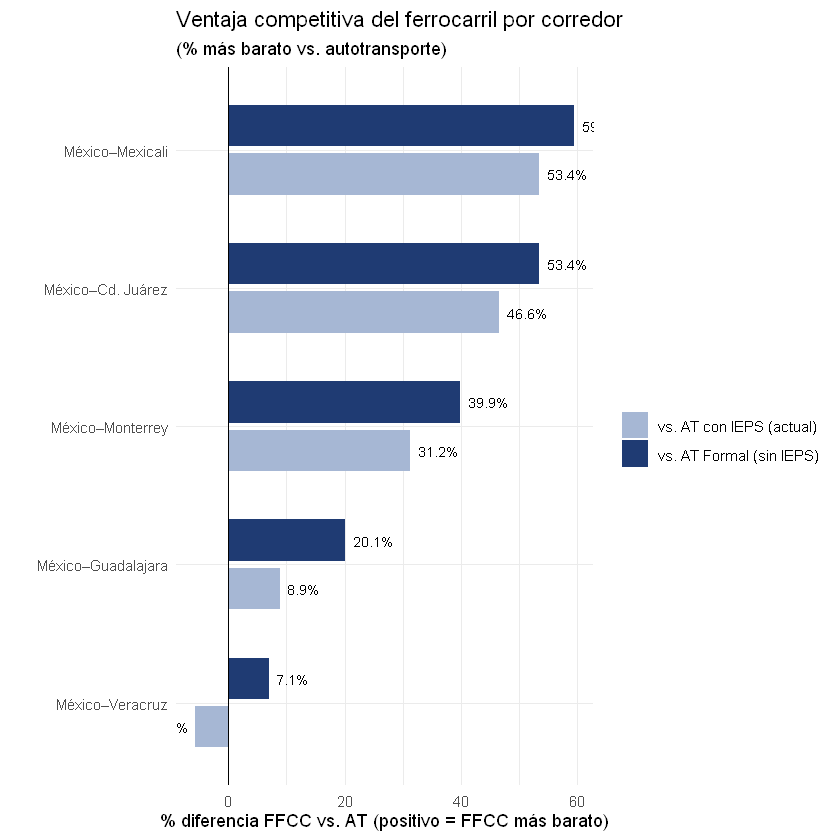

In [ ]:
###Figura 3

ggplot(df_plot_bar, aes(x = valor, y = corredor, fill = tipo)) +

  geom_col(position = position_dodge(width = 0.7), width = 0.6) +

  geom_vline(xintercept = 0, color = "black", size = 0.5) +
geom_text(
    aes(label = paste0(round(valor,1), "%")),
    position = position_dodge(width = 0.7),
    hjust = ifelse(df_plot_bar$valor > 0, -0.2, 1.2),
    size = 3
  )+
  scale_fill_manual(values = c(
    "vs. AT Formal (sin IEPS)" = "#1f3b73",
    "vs. AT con IEPS (actual)" = "#a6b7d4"
  )) +

  labs(
    title = "Ventaja competitiva del ferrocarril por corredor",
    subtitle = "(% más barato vs. autotransporte)",
    x = "% diferencia FFCC vs. AT (positivo = FFCC más barato)",
    y = "",
    fill = ""
  ) +

  theme_minimal()